# Week 10 – Colab 3: Detection Pipeline Starter (Assignment 4)

In this notebook you will:

1. Install and load a **pre-trained YOLO** object detector  
2. Run detection on a sample image  
3. Extract detected labels from the model output  
4. Design a **simple "robot brain"** that reacts to detections

This is a **starting point for Assignment 4**, where you'll build your own detection-based system.


In [ ]:
#@title Install YOLO (Ultralytics)

!pip install -q ultralytics

from ultralytics import YOLO
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
#@title Load Pre-Trained YOLO Model

# We use a small YOLOv8 model pre-trained on COCO dataset
# This recognises common objects like person, bus, car, etc.

model = YOLO("yolov8n.pt")  # 'n' = nano (small & fast)
model.to(device)


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

Removed existing corrupted image file.
Downloaded sample image: sample_bus.jpg


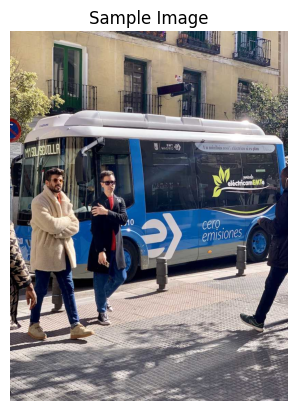

In [ ]:
import os
import urllib.request

image_url = "https://ultralytics.com/images/bus.jpg"
image_path = "sample_bus.jpg"

# Ensure a fresh download of the image, even if it exists, to fix potential corruption.
# This removes the existing file before downloading a new one.
if os.path.exists(image_path):
    os.remove(image_path)
    print("Removed existing corrupted image file.")

urllib.request.urlretrieve(image_url, image_path)
print("Downloaded sample image:", image_path)

# Show the image
img = Image.open(image_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.title("Sample Image")
plt.show()


image 1/1 /content/sample_bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 76.4ms
Speed: 10.3ms preprocess, 76.4ms inference, 7.4ms postprocess per image at shape (1, 3, 640, 480)
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: '

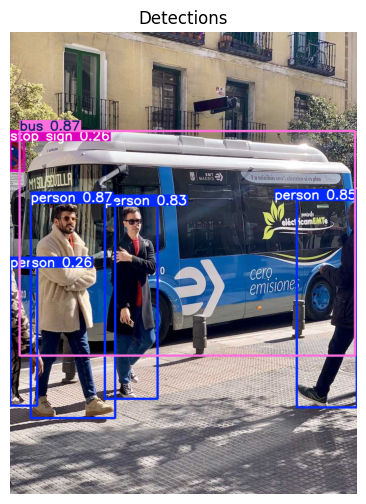

In [ ]:
#@title Run YOLO Detection on the Sample Image

# Run the detector (results is a list, we take the first element)
results = model(image_path)

result = results[0]
print(result)  # quick summary

# Plot the image with bounding boxes drawn by YOLO
annotated_img = result.plot()  # returns a numpy array (BGR)
annotated_img = annotated_img[:, :, ::-1]  # convert BGR -> RGB

plt.figure(figsize=(8, 6))
plt.imshow(annotated_img)
plt.axis("off")
plt.title("Detections")
plt.show()


In [ ]:
#@title Extract Detected Labels from the Result

boxes = result.boxes

# Class indices (e.g. 0 = person, 2 = car, etc.)
class_ids = boxes.cls.tolist()
class_ids = [int(c) for c in class_ids]

# Map class IDs to human-readable labels using result.names
names = result.names
labels = [names[c] for c in class_ids]

print("Detected labels:", labels)

# Count how many 'person' detections we have
num_person = labels.count("person")
print("Number of 'person' detections:", num_person)


Detected labels: ['bus', 'person', 'person', 'person', 'person', 'stop sign']
Number of 'person' detections: 4


In [ ]:
#@title Simple Robot Brain (Edit This for Your Concept)

def simple_robot_brain(labels):
    """
    This function represents the 'brain' of your robot.
    It receives a list of detected labels (e.g. ['person', 'bus', 'person'])
    and decides what the robot should do.
    """

    num_person = labels.count("person")
    num_bus = labels.count("bus")

    # ==== STUDENT: THIS IS YOUR MAIN PLAYGROUND ====
    # You can completely change the logic below to fit your idea.

    if num_person > 0:
        print(f"Robot: I see {num_person} human(s). I will wave hello 👋")
    else:
        print("Robot: No humans detected. I will look around...")

    if num_bus > 0:
        print("Robot: There's a bus! I will move out of the way 🚌")
    else:
        print("Robot: No bus detected. I can safely stay here.")

# Run our simple robot brain on the detected labels from the sample image
simple_robot_brain(labels)


Robot: I see 4 human(s). I will wave hello 👋
Robot: There's a bus! I will move out of the way 🚌


Saving images.jpg to images.jpg
Running detection on: images.jpg

0: 448x640 4 persons, 2 buss, 60.4ms
Speed: 2.5ms preprocess, 60.4ms inference, 3.8ms postprocess per image at shape (1, 3, 448, 640)


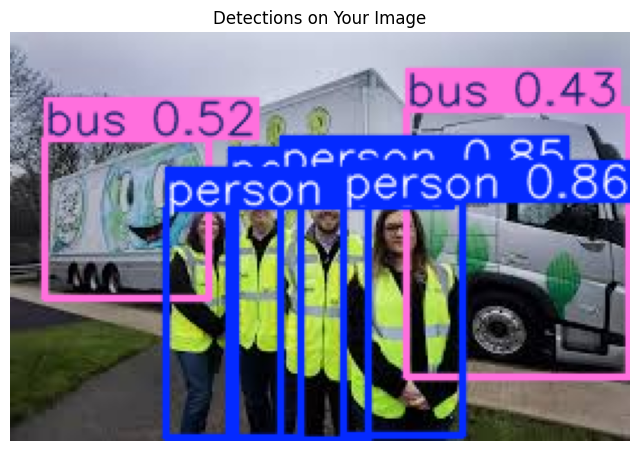

Detected labels: ['person', 'person', 'person', 'person', 'bus', 'bus']
Robot reaction:
Robot: I see 4 human(s). I will wave hello 👋
Robot: There's a bus! I will move out of the way 🚌


In [ ]:
#@title OPTIONAL: Upload Your Own Image and Try Detection

from google.colab import files

uploaded = files.upload()  # choose an image file from your computer

for filename in uploaded.keys():
    print("Running detection on:", filename)
    img = Image.open(filename).convert("RGB")

    # Run YOLO
    results_custom = model(img)
    result_custom = results_custom[0]

    annotated_img_custom = result_custom.plot()
    annotated_img_custom = annotated_img_custom[:, :, ::-1]

    plt.figure(figsize=(8, 6))
    plt.imshow(annotated_img_custom)
    plt.axis("off")
    plt.title("Detections on Your Image")
    plt.show()

    # Extract labels
    boxes_custom = result_custom.boxes
    class_ids_custom = [int(c) for c in boxes_custom.cls.tolist()]
    labels_custom = [result_custom.names[c] for c in class_ids_custom]

    print("Detected labels:", labels_custom)
    print("Robot reaction:")
    simple_robot_brain(labels_custom)


## ✏️ Planning for Assignment 4

Using this notebook as a starting point, write **3–5 bullet points** about your idea:

- Which **pre-trained model** will you use? (YOLO, face detector, etc.)
- What is your **robotic scenario**?
- What will your **robot brain** do when it sees:
  - a person?
  - a certain object?
  - no detections?
- Will your robot be **physical** or **simulated on screen**?
- How could you extend this with:
  - sound?
  - lights?
  - movement patterns?

You can type your notes directly in this notebook, or keep them in your project plan.
